# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Sebastian Hernandez Gutierrez"            # Tu nombre completo
MATRICULA = "45857"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "pib"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Sebastian Hernandez Gutierrez
Matrícula: 45857
Dataset asignado: pib


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


/Users/sebastian_hdz_gtz/Documents/Big_Data/U1_1_Probabilidad_estadistica/.venv/bin/python


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: pib
Descripcion: PIB per capita (dolares constantes de 2015) (USD)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,308.31827
1,Afghanistan,AFG,2001,277.11804
2,Afghanistan,AFG,2002,338.13998
3,Afghanistan,AFG,2003,346.07162
4,Afghanistan,AFG,2004,338.63727
5,Afghanistan,AFG,2005,363.64014
6,Afghanistan,AFG,2006,367.75830
7,Afghanistan,AFG,2007,410.75772
8,Afghanistan,AFG,2008,417.64728
9,Afghanistan,AFG,2009,488.83066


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(12384, 4)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12384 entries, 0 to 12383
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  12384 non-null  str    
 1   code    12384 non-null  str    
 2   year    12384 non-null  int64  
 3   valor   12384 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 387.1 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count     12384.000000
mean      12434.415310
std       19221.293985
min         122.678900
25%        1370.694600
50%        4089.543600
75%       16127.642000
max      247170.110000
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*Al observar los resultados, note que existen valores nulos en la columna de código o en la de 'valor', probablemente corresponden a regiones agregadas o años sin medición. La variable 'valor' es de tipo flotante y representa dólares constantes.*

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [ ]:
# Pregunta 1
df_paises = df[df[config["filtro_paises"]].notnull()].copy()

num_paises = df_paises['entity'].nunique()
print(f"Existen {num_paises} países distintos.")


anio_reciente = df_paises['year'].max()
df_reciente = df_paises[df_paises['year'] == anio_reciente]

top_10 = df_reciente.sort_values('valor', ascending=False).head(10)
bottom_10 = df_reciente.sort_values('valor', ascending=True).head(10)

print(f"\nTop 10 países con mayor PIB ({anio_reciente}):\n", top_10[['entity', 'valor']])
print(f"\nTop 10 países con menor PIB ({anio_reciente}):\n", bottom_10[['entity', 'valor']])


Existen 226 países distintos.

Top 10 países con mayor PIB (2025):
                    entity       valor
5397              Ireland  104416.836
6624           Luxembourg  103292.150
10882         Switzerland   93327.590
8437               Norway   83812.760
10014           Singapore   70683.680
11809       United States   67945.620
6668                Macao   66444.080
8314   North America (WB)   65507.547
2861              Denmark   62217.610
9211                Qatar   61734.690

Top 10 países con menor PIB (2025):
                              entity      valor
1689                        Burundi  273.43298
2003       Central African Republic  393.98830
6734                     Madagascar  456.50967
10215                       Somalia  465.43940
6800                         Malawi  548.16046
2795   Democratic Republic of Congo  567.56030
10684                         Sudan  582.11410
7683                     Mozambique  585.68260
8182                          Niger  610.37555
6330  

**Interpretación:**

*Se puede apreciar que existe una gran desigualdad economica por los 226 paises, la riqueza esta fuertmenete centrada en naciones europeas en cambio los paises con menor ingreso son paises africanos, esto no hace ver la gran brecha de desarrollo y extrema desigualdad y vulnerabilidad regional*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [11]:
# Pregunta 2
paises_p2 = ["Mexico", "United States"]

anios_mex = df_paises[df_paises['entity'] == 'Mexico']['year'].dropna().unique()
anios_usa = df_paises[df_paises['entity'] == 'United States']['year'].dropna().unique()

anios_comunes = np.intersect1d(anios_mex, anios_usa)

df_p2 = df_paises[(df_paises['entity'].isin(paises_p2)) & (df_paises['year'].isin(anios_comunes))]
df_p2.head()


,entity,code,year,valor
7225,Mexico,MEX,1960,4145.7930
7226,Mexico,MEX,1961,4219.1816
7227,Mexico,MEX,1962,4276.1430
7228,Mexico,MEX,1963,4474.7275
7229,Mexico,MEX,1964,4845.8745


**Interpretación:**

*La tabla inicial nos muestra que, en esos primeros cinco años de registro compartido, el PIB per cápita de México mantenía un crecimiento constante, arrancando en 4,145 USD*

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [12]:
# Pregunta 3
paises_5 = ["Mexico", "China", "Germany", "South Africa", "Australia"]
anio_reciente = df_paises['year'].max()

df_p3 = df_paises[(df_paises['entity'].isin(paises_5)) & (df_paises['year'] == anio_reciente)]

df_p3 = df_p3.sort_values(by='valor', ascending=False)
mas_alto = df_p3.iloc[0]
mas_bajo = df_p3.iloc[-1]

diferencia = mas_alto['valor'] - mas_bajo['valor']

print(f"El valor más alto es de {mas_alto['entity']} con {mas_alto['valor']:,.2f} USD")
print(f"El valor más bajo es de {mas_bajo['entity']} con {mas_bajo['valor']:,.2f} USD")
print(f"La diferencia absoluta es: {diferencia:,.2f} USD")

El valor más alto es de Australia con 61,368.61 USD
El valor más bajo es de South Africa con 5,713.12 USD
La diferencia absoluta es: 55,655.49 USD


**Interpretación:**

*Se puede apreciar que de los 5 paies que seleccione tienen una gran brecha economica, Australia supera el ingreso promedio de Sudafrica por más de diez veces, demostrando que la riqueza que tienen las naciones desarrolladas y las naciones emergentes es ,uy distinta*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [13]:
# Pregunta 4
latam = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]
anio_reciente = df_paises['year'].max()

df_latam = df_paises[(df_paises['entity'].isin(latam)) & (df_paises['year'] == anio_reciente)]
df_asia = df_paises[(df_paises['entity'].isin(asia)) & (df_paises['year'] == anio_reciente)]

promedio_latam = df_latam['valor'].mean() 
promedio_asia = df_asia['valor'].mean()

print(f"Promedio Latam ({anio_reciente}): {promedio_latam:,.2f} USD")
print(f"Promedio Asia ({anio_reciente}): {promedio_asia:,.2f} USD")


Promedio Latam (2025): 10,173.12 USD
Promedio Asia (2025): 18,906.92 USD


**Interpretación:**

*Se puede apreciar que existe una gran diferencia entre cada bloque el bloque de latinoamerica esta liderado por mexico que es el que mas Pib aporta de su grupo, mientras tanto en Asia la potencia que es china y japon hace que se supere por mucho al bloque de latinoamerica*

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [14]:
# Pregunta 5
df_mex = df_paises[df_paises['entity'] == 'Mexico'].dropna(subset=['valor'])

entidad_min_idx = df_mex['valor'].idxmin()
entidad_max_idx = df_mex['valor'].idxmax()

anio_min = df_mex.loc[entidad_min_idx, 'year'] 
valor_min = df_mex.loc[entidad_min_idx, 'valor'] 

anio_max = df_mex.loc[entidad_max_idx, 'year']
valor_max = df_mex.loc[entidad_max_idx, 'valor']

print(f"Valor mínimo: {valor_min:,.2f} en {anio_min}")
print(f"Valor máximo: {valor_max:,.2f} en {anio_max}")


Valor mínimo: 4,145.79 en 1960
Valor máximo: 10,296.87 en 2018


**Interpretación:**

*se puede observar que el valor mas minimo que tuvo mexico fue en 1960, mientras que el mas alto fue 2018, se puede ver que en 58 años la tendencia a largo plazo fue creciente, eso quiere decir que la expancion economica de mexico avanzo aunque el pais este pasando por crisis*

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [15]:
# Pregunta 6
df_mex = df_paises[df_paises['entity'] == 'Mexico'].sort_values('year').dropna(subset=['valor'])

primer_registro = df_mex.iloc[0]
ultimo_registro = df_mex.iloc[-1]

cambio_pct = ((ultimo_registro['valor'] - primer_registro['valor']) / primer_registro['valor']) * 100

print(f"Cambio porcentual desde {primer_registro['year']} hasta {ultimo_registro['year']}: {cambio_pct:.2f}%")


Cambio porcentual desde 1960 hasta 2025: 147.40%


**Interpretación:**

*se puede ver que el cambio porcentual desde el momento mas bajo hasta el mas alto fue de 147.40% esto se debe a que el pais paso de una traformacion agricola a un pais industrializado gracias a las inversiones extranjeras y inversiones internas del pais*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [16]:
# Pregunta 7
anio_reciente = df_paises['year'].max()
df_reciente = df_paises[df_paises['year'] == anio_reciente].dropna(subset=['valor'])

valores_np = df_reciente['valor'].to_numpy()

media = np.mean(valores_np)
mediana = np.median(valores_np)
desviacion = np.std(valores_np)

print(f"--- Estadísticas Globales ({anio_reciente}) ---")
print(f"Media: {media:,.2f}")
print(f"Mediana: {mediana:,.2f}")
print(f"Desviación Estándar: {desviacion:,.2f}")


--- Estadísticas Globales (2025) ---
Media: 15,459.02
Mediana: 6,782.75
Desviación Estándar: 20,190.97


**Interpretación:**

*se puede apreciar que la media es de 15,459.02 USD es mas del doble que la mediana, esto indica que la distribución del PIB global no es simetrico, esta muy sesgada hacia arriba por un grupo pequeño de paises que son extremadamente ricos, mientras que la desviacion estandar es muy grande superando a la media, esto representa la gran variabilidad de datos, esto nos hace ver que existe una desigualdad economica muy grande entre las naciones pobres y las potencias globales*

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

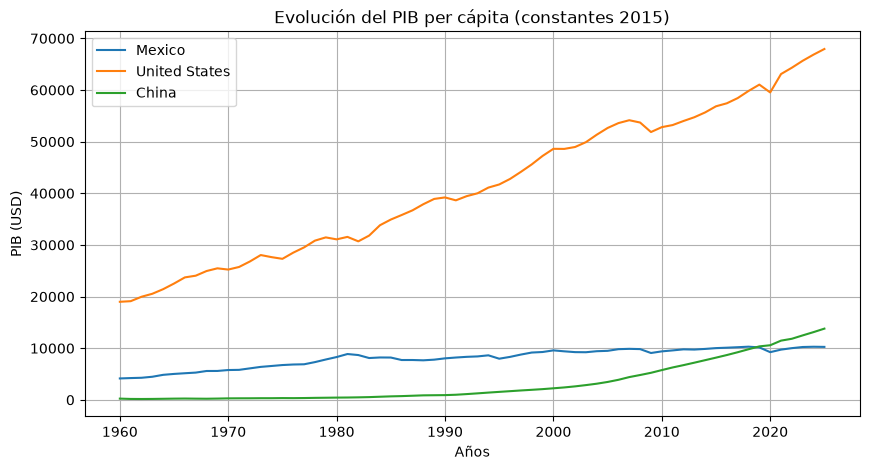

In [17]:
# Pregunta 8
paises_graficar = ["Mexico", "United States", "China"]
plt.figure(figsize=(10, 5))

for pais in paises_graficar:
    df_plot = df_paises[df_paises['entity'] == pais]
    plt.plot(df_plot['year'], df_plot['valor'], label=pais)

plt.title("Evolución del PIB per cápita (constantes 2015)")
plt.xlabel("Años")
plt.ylabel(f"PIB ({config['unidad']})")
plt.grid(True)
plt.legend()
plt.show()


**Interpretación:**

*En esta grafica se puede apreciar que estados unidos desde el principios de 1960 ya tenia un alza muy grande y fue y sigue creciendo de una manera muy abrupta, mientras que mexico su crecimiento pareceria bueno, pero en realidad se ve muy constante y casi lineal y por ultimo china al parecer su crecimiento no empezo hasta 1980 que es donde empieza a subir la grafica superando a mexico*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

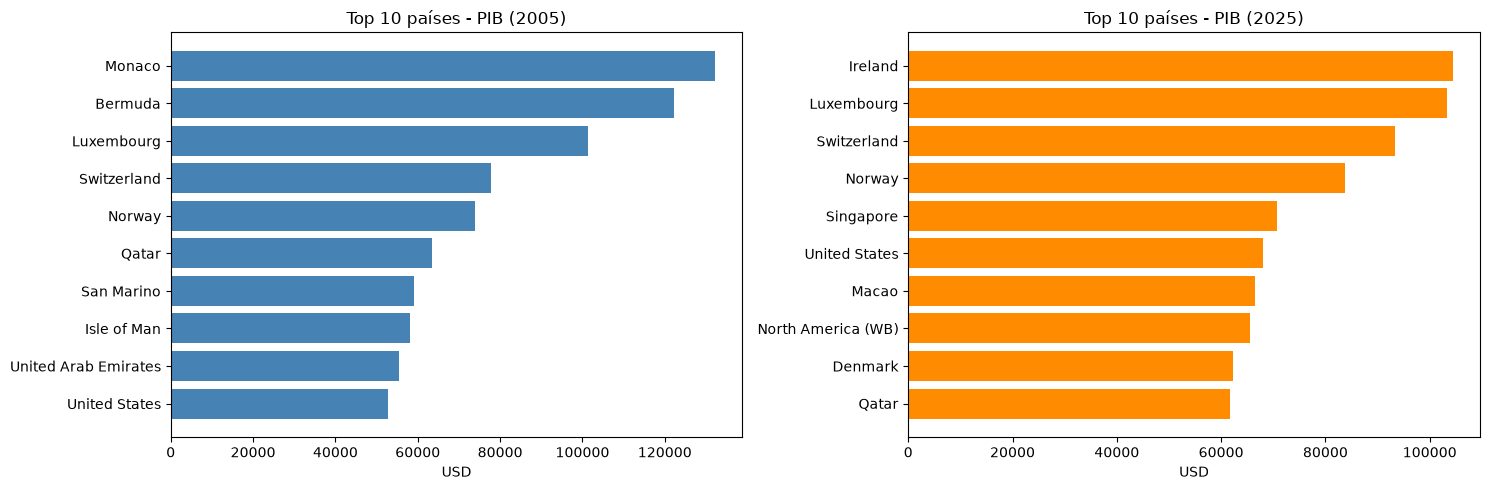

In [18]:
# Pregunta 9
anio_nacimiento = 2005
anio_actual = df_paises['year'].max()

top_nac = df_paises[df_paises['year'] == anio_nacimiento].sort_values('valor', ascending=False).head(10)
top_act = df_paises[df_paises['year'] == anio_actual].sort_values('valor', ascending=False).head(10)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top_nac['entity'], top_nac['valor'], color='steelblue') 
axes[0].set_title(f"Top 10 países - PIB ({anio_nacimiento})")
axes[0].set_xlabel("USD")
axes[0].invert_yaxis()

axes[1].barh(top_act['entity'], top_act['valor'], color='darkorange') 
axes[1].set_title(f"Top 10 países - PIB ({anio_actual})")
axes[1].set_xlabel("USD")
axes[1].invert_yaxis() 

plt.tight_layout()
plt.show()


**Interpretación:**

*En las graficas se puede apreciar que en 2005 estaba fuertemente dominado por territorios conocidos por ventajas fiscales, estos desaprarecen de los primeros puesto para 2025 dando paso a Irlanda y potencias como Singapur y Macao, que son paises albergan sedes multinacionales tecnologicas, tambien se puede apreciar que aunque la tabla cambio mucho paises como Luxemburgo, Suiza, Noruega y Estados Unidos tienen una estabilidad mantenniendose en el top 10 en los ultimos 20 años, tambien se puede apreciar que mejoro la consentracion de riqueza de los paises *

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*A lo largo de este análisis sobre el PIB per cápita, aprendí que existe una profunda y persistente desigualdad económica a nivel global, con patrones que revelan una fuerte concentración de la riqueza en Europa y Norteamérica, en drástico contraste con el rezago del continente africano, tambien puede observar que el mundo esta controlado por solo unos pocos paises los cuales tiene el control de la economia global; otra cosa que se me hizo interestante esque al final todos los paises tuvieron un crecimiento en los utlimos años por muy pequeño que sea pero eso no se puede reflejar en bienestar*

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
